# CEAL Eye Re-Crop — All Aug IDs (Tighter Bounding Boxes)

**Problem:** The existing CEAL eye crops used `eye_expand=0.40` (40% padding),
built for iTracker. GazeNet was trained on tighter crops (~15% expansion).

**Approach:** Run MediaPipe on the existing 224×224 face crops (which exist for
all aug_ids 0-3) to detect eye landmarks, then crop tighter eyes. This ensures
augmentation consistency — the color jitter, blur, etc. are already baked into
the face crop, and the eye crops inherit them.

**Processes all aug_ids** so we can do apples-to-apples comparison with the
iTracker baseline, which also ran on all aug_ids.

**Outputs:**
- New eye crops at 224×224 (tighter field of view)
- Face crops copied into new folder (self-contained)
- New manifest CSV with all paths pointing to new folder

In [1]:
import numpy as np
import pandas as pd
import mediapipe as mp
import shutil
from pathlib import Path
from PIL import Image
from tqdm import tqdm

In [2]:
# ============================================================
# PATHS
# ============================================================

# Source: old iTracker artifacts (has all aug_ids, 40% eye crops)
OLD_ARTIFACTS = Path("/Volumes/Crucial X10/210/data/ceal_itracker_artifacts")
OLD_MANIFEST  = OLD_ARTIFACTS / "manifest.csv"

# Destination: new GazeNet artifacts (tighter eye crops)
NEW_ARTIFACTS = Path("/Volumes/Crucial X10/210/data/ceal_gazenet_artifacts")
NEW_MANIFEST  = NEW_ARTIFACTS / "manifest.csv"

# Eye expansion factor
EYE_EXPAND = 0.15   # was 0.40 for iTracker

# Crop output size
CROP_SIZE = 224

print(f"Source:      {OLD_ARTIFACTS}")
print(f"Destination: {NEW_ARTIFACTS}")
print(f"Eye expand:  {EYE_EXPAND} (was 0.40)")

Source:      /Volumes/Crucial X10/210/data/ceal_itracker_artifacts
Destination: /Volumes/Crucial X10/210/data/ceal_gazenet_artifacts
Eye expand:  0.15 (was 0.40)


In [3]:
# ============================================================
# LOAD OLD MANIFEST — all aug_ids, status=ok only
# ============================================================

df_old = pd.read_csv(OLD_MANIFEST)
print(f"Old manifest: {len(df_old)} rows total")
print(f"Status breakdown:\n{df_old['status'].value_counts()}")

df = df_old[df_old['status'] == 'ok'].copy()
print(f"\nAfter filtering (status=ok): {len(df)} samples")
print(f"Aug ID breakdown:\n{df['aug_id'].value_counts().sort_index()}")
print(f"Subjects: {df['subject'].nunique()}")

Old manifest: 23520 rows total
Status breakdown:
status
ok    23520
Name: count, dtype: int64

After filtering (status=ok): 23520 samples
Aug ID breakdown:
aug_id
0    5880
1    5880
2    5880
3    5880
Name: count, dtype: int64
Subjects: 56


In [4]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

mp_face_mesh = mp.solutions.face_mesh

LEFT_EYE_IDX = sorted({i for edge in mp_face_mesh.FACEMESH_LEFT_EYE for i in edge})
RIGHT_EYE_IDX = sorted({i for edge in mp_face_mesh.FACEMESH_RIGHT_EYE for i in edge})

def _landmarks_to_xy_px(landmarks, w, h):
    xs = np.array([lm.x for lm in landmarks], dtype=np.float32) * w
    ys = np.array([lm.y for lm in landmarks], dtype=np.float32) * h
    return xs, ys

def _bbox_from_points(xs, ys, pad_frac=0.0):
    x0, y0 = xs.min(), ys.min()
    x1, y1 = xs.max(), ys.max()
    bw, bh = x1 - x0, y1 - y0
    pad_x, pad_y = bw * pad_frac, bh * pad_frac
    return np.array([x0 - pad_x, y0 - pad_y, x1 + pad_x, y1 + pad_y], dtype=np.float32)

def _clamp_bbox(bbox, w, h):
    x0, y0, x1, y1 = bbox
    return np.array([
        float(np.clip(x0, 0, w - 1)),
        float(np.clip(y0, 0, h - 1)),
        float(np.clip(x1, 0, w - 1)),
        float(np.clip(y1, 0, h - 1)),
    ], dtype=np.float32)

def _is_bbox_valid(bbox, min_size_px=10.0):
    x0, y0, x1, y1 = bbox
    return (x1 > x0 + min_size_px) and (y1 > y0 + min_size_px)

def bbox_float_to_int(bbox):
    x0, y0, x1, y1 = bbox
    return int(np.floor(x0)), int(np.floor(y0)), int(np.ceil(x1)), int(np.ceil(y1))

def crop_from_bbox(img_np, bbox, min_px=10):
    h, w = img_np.shape[:2]
    x0, y0, x1, y1 = bbox_float_to_int(bbox)
    x0, y0 = max(0, x0), max(0, y0)
    x1, y1 = min(w, x1), min(h, y1)
    if x1 <= x0 or y1 <= y0 or (x1 - x0) < min_px or (y1 - y0) < min_px:
        return None
    return img_np[y0:y1, x0:x1]

def save_crop(crop_np, out_path, size=CROP_SIZE):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    pil_img = Image.fromarray(crop_np)
    pil_img = pil_img.resize((size, size), Image.BILINEAR)
    pil_img.save(out_path, format="JPEG", quality=95, optimize=True)

print(f"Helpers ready")
print(f"Left eye landmarks:  {len(LEFT_EYE_IDX)} indices")
print(f"Right eye landmarks: {len(RIGHT_EYE_IDX)} indices")

Helpers ready
Left eye landmarks:  16 indices
Right eye landmarks: 16 indices


I0000 00:00:1772922830.547335       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


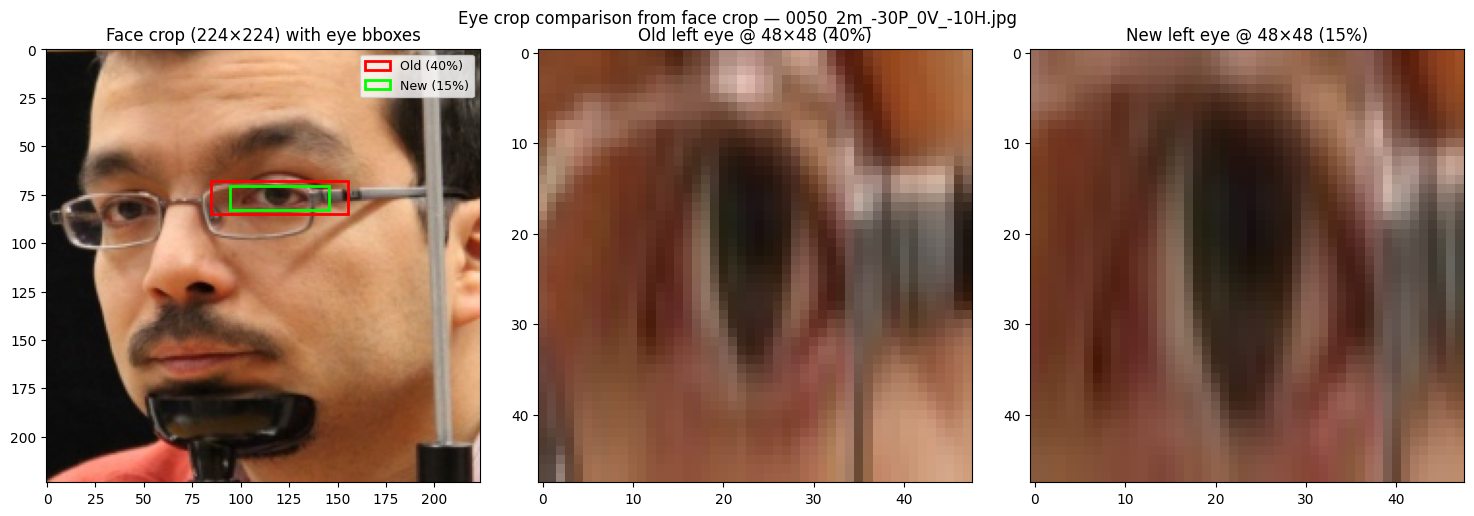

In [5]:
# ============================================================
# VISUAL SANITY CHECK — compare old vs new crop on one sample
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Pick a sample (aug_id=0)
sample_row = df[df['aug_id'] == 0].iloc[0]
face_img = Image.open(sample_row['face_path']).convert('RGB')
face_np = np.array(face_img)
h, w = face_np.shape[:2]

# Run MediaPipe on the face crop
with mp_face_mesh.FaceMesh(
    static_image_mode=True, max_num_faces=1,
    refine_landmarks=True, min_detection_confidence=0.5,
) as fm:
    results = fm.process(face_np)

if results.multi_face_landmarks:
    lms = results.multi_face_landmarks[0].landmark
    xs, ys = _landmarks_to_xy_px(lms, w, h)
    left_xs, left_ys = xs[LEFT_EYE_IDX], ys[LEFT_EYE_IDX]

    # Old bbox (40%)
    left_old = _clamp_bbox(_bbox_from_points(left_xs, left_ys, pad_frac=0.40), w, h)
    # New bbox (15%)
    left_new = _clamp_bbox(_bbox_from_points(left_xs, left_ys, pad_frac=EYE_EXPAND), w, h)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Face crop with both bboxes
    axes[0].imshow(face_np)
    for bbox, color, label in [
        (left_old, 'red', 'Old (40%)'),
        (left_new, 'lime', f'New ({int(EYE_EXPAND*100)}%)'),
    ]:
        x0, y0, x1, y1 = bbox
        rect = patches.Rectangle((x0, y0), x1-x0, y1-y0,
                                  linewidth=2, edgecolor=color, facecolor='none', label=label)
        axes[0].add_patch(rect)
    axes[0].legend(fontsize=9)
    axes[0].set_title('Face crop (224×224) with eye bboxes')

    # Old eye crop at 48×48
    old_crop = crop_from_bbox(face_np, left_old)
    if old_crop is not None:
        axes[1].imshow(np.array(Image.fromarray(old_crop).resize((48, 48))))
        axes[1].set_title('Old left eye @ 48×48 (40%)')

    # New eye crop at 48×48
    new_crop = crop_from_bbox(face_np, left_new)
    if new_crop is not None:
        axes[2].imshow(np.array(Image.fromarray(new_crop).resize((48, 48))))
        axes[2].set_title(f'New left eye @ 48×48 ({int(EYE_EXPAND*100)}%)')

    plt.suptitle(f'Eye crop comparison from face crop — {sample_row["orig_filename"]}', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("MediaPipe failed on sample face crop — try another sample")

In [ ]:
# ============================================================
# RE-CROP ALL EYES (ALL AUG_IDS) + BUILD NEW MANIFEST
#
# For each row in the old manifest:
#   1. Load the 224×224 face crop (exists for all aug_ids)
#   2. Run MediaPipe on the face crop to find eye landmarks
#   3. Crop eyes with tight expansion (0.15)
#   4. Save new eye crops at 224×224
#   5. Copy face crop into new folder (self-contained)
#   6. Write new manifest row
#
# Estimated time: ~50 min on M1 for ~23K samples
# ============================================================

NEW_ARTIFACTS.mkdir(parents=True, exist_ok=True)

new_rows = []
fail_count = 0
fail_reasons = {'no_face': 0, 'bad_bbox': 0, 'bad_crop': 0, 'missing_face': 0}

with mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
) as face_mesh:

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Re-cropping eyes"):
        subject = str(row['subject'])
        aug_id = int(row['aug_id'])
        stem = Path(row['orig_filename']).stem

        # ---- Load face crop ----
        old_face_path = Path(row['face_path'])
        if not old_face_path.exists():
            fail_count += 1
            fail_reasons['missing_face'] += 1
            continue

        face_img = Image.open(old_face_path).convert('RGB')
        face_np = np.array(face_img)
        h, w = face_np.shape[:2]

        # ---- Run MediaPipe on face crop ----
        results = face_mesh.process(face_np)
        if not results.multi_face_landmarks:
            fail_count += 1
            fail_reasons['no_face'] += 1
            continue

        lms = results.multi_face_landmarks[0].landmark
        xs, ys = _landmarks_to_xy_px(lms, w, h)

        # ---- Eye bboxes with tight expansion ----
        left_xs, left_ys = xs[LEFT_EYE_IDX], ys[LEFT_EYE_IDX]
        right_xs, right_ys = xs[RIGHT_EYE_IDX], ys[RIGHT_EYE_IDX]

        left_bbox  = _clamp_bbox(_bbox_from_points(left_xs, left_ys, pad_frac=EYE_EXPAND), w, h)
        right_bbox = _clamp_bbox(_bbox_from_points(right_xs, right_ys, pad_frac=EYE_EXPAND), w, h)

        if not (_is_bbox_valid(left_bbox) and _is_bbox_valid(right_bbox)):
            fail_count += 1
            fail_reasons['bad_bbox'] += 1
            continue

        # ---- Crop eyes ----
        left_crop  = crop_from_bbox(face_np, left_bbox)
        right_crop = crop_from_bbox(face_np, right_bbox)

        if left_crop is None or right_crop is None:
            fail_count += 1
            fail_reasons['bad_crop'] += 1
            continue

        # ---- Save new eye crops ----
        left_path  = NEW_ARTIFACTS / subject / f"{stem}_aug{aug_id}_left.jpg"
        right_path = NEW_ARTIFACTS / subject / f"{stem}_aug{aug_id}_right.jpg"
        save_crop(left_crop, left_path)
        save_crop(right_crop, right_path)

        # ---- Copy face crop (self-contained folder) ----
        new_face_path = NEW_ARTIFACTS / subject / f"{stem}_aug{aug_id}_face.jpg"
        new_face_path.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(old_face_path, new_face_path)

        # ---- Manifest row ----
        new_rows.append({
            'sample_id': row['sample_id'],
            'subject': subject,
            'orig_path': row['orig_path'],
            'orig_filename': row['orig_filename'],
            'aug_id': aug_id,
            'face_path': str(new_face_path),
            'left_path': str(left_path),
            'right_path': str(right_path),
            'head_pose_deg': row['head_pose_deg'],
            'gaze_vertical_deg': row['gaze_vertical_deg'],
            'gaze_horizontal_deg': row['gaze_horizontal_deg'],
            'status': 'ok',
            'eye_expand': EYE_EXPAND,
        })

# Write manifest
df_new = pd.DataFrame(new_rows)
df_new.to_csv(NEW_MANIFEST, index=False)

print(f"\nDone!")
print(f"  Successful: {len(df_new)}")
print(f"  Failed:     {fail_count}")
if fail_count > 0:
    print(f"  Reasons:    {fail_reasons}")
print(f"  Manifest:   {NEW_MANIFEST}")
print(f"\nAug ID breakdown:")
print(df_new['aug_id'].value_counts().sort_index())

In [ ]:
# ============================================================
# VERIFY
# ============================================================

import matplotlib.pyplot as plt

df_check = pd.read_csv(NEW_MANIFEST)
print(f"New manifest: {len(df_check)} rows")
print(f"Aug ID breakdown:\n{df_check['aug_id'].value_counts().sort_index()}")
print(f"Subjects: {df_check['subject'].nunique()}")

# Spot check one sample per aug_id
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for col, aug_id in enumerate(sorted(df_check['aug_id'].unique())[:4]):
    sample = df_check[df_check['aug_id'] == aug_id].sample(1, random_state=42).iloc[0]

    face = Image.open(sample['face_path'])
    left = Image.open(sample['left_path'])

    axes[0, col].imshow(face)
    axes[0, col].set_title(f'Face (aug={aug_id})')
    axes[0, col].axis('off')

    axes[1, col].imshow(left)
    axes[1, col].set_title(f'Left eye (aug={aug_id})')
    axes[1, col].axis('off')

plt.suptitle('Spot check: face + left eye per aug_id', fontsize=13)
plt.tight_layout()
plt.show()

# Verify sizes
sample = df_check.iloc[0]
print(f"\nSample sizes:")
print(f"  face:  {Image.open(sample['face_path']).size}")
print(f"  left:  {Image.open(sample['left_path']).size}")
print(f"  right: {Image.open(sample['right_path']).size}")